# Smart Agriculture AI-Assisted Labeling Project

## 1. Data Understanding (데이터 이해)

### DU-01. Project & Dataset Overview (프로젝트 및 데이터셋 개요)

본 프로젝트는 Smart Agriculture(스마트 농업) 환경의 작물 및 잡초 이미지를 활용하여 
Computer Vision(컴퓨터 비전) 기반 데이터 라벨링 과정을 수행하는 것을 목적으로 한다.

기존의 Manual Labeling(수동 라벨링)뿐만 아니라 AI-Assisted Labeling(AI 보조 라벨링)과 
Auto Labeling(자동 라벨링)을 함께 적용하여 라벨링 방식에 따른 품질과 작업 효율성을 비교한다. 

프로젝트에서는 CropAndWeed Dataset(작물 및 잡초 데이터셋)을 활용하며,
실제 농경지에서 촬영된 이미지와 기존 Ground Truth(정답 라벨)를 기반으로 
Crop(작물)과 Weed(잡초)의 객체 및 영역 정보를 분석한다. 

### Project Objectives (프로젝트 목표)

- Smart Agriculture Image(스마트 농업 이미지)의 구조와 객체 특성을 이해한다.
- Crop(작물)과 Weed(잡초)를 대상으로 Segmentation Labeling(분할 라벨링)을 수행한다.
- Manual Labeling(수동 라벨링)과 AI-Assisted Labeling(AI 보조 라벨링)을 비교한다.
- Auto Labeling(자동 라벨링) 결과에 Human Review(사람 검수)를 적용한다.
- Ground Truth(정답 라벨)를 활용하여 IoU(Intersection over Union) 등의 품질 지표를 평가한다.
- 이미지 및 객체 난이도에 따른 Auto Labeling 성능 차이를 분석한다.
- 라벨링 품질과 작업시간을 함께 측정하여 AI 활용에 따른 생산성 변화를 평가한다.


### Dataset Overview (데이터셋 개요)

본 프로젝트에서는 CropAndWeed Dataset을 사용한다. 

CropAndWeed Dataset은 실제 농업 환경에서 촬영된 Crop(작물)과 Weed(잡초) 이미지로 구성되어 있으며,
객체 탐지 및 이미지 분할 연구를 위한 다양한 Annotation(라벨) 정보를 제공한다.

본 프로젝트에서 확인할 주요 데이터 구성은 다음과 같다.

- `images/` : 원본 RGB Image(이미지)
- `bboxes/` : Bounding Box(바운딩 박스) 라벨
- `labelIds/` : Pixel-level Label(픽셀 단위 라벨)
- `params/` : 이미지 및 객체 관련 Parameter(파라미터)

전체 Dataset을 그대로 라벨링에 사용하는 대신 Data Understanding(데이터 이해)을 통해
이미지와 객체의 특성을 분석한 후 Pilot Dataset(파일럿 데이터셋)을 선정한다.

선정된 이미지는 이후 Manual Labeling, AI-Assisted Labeling 및 Auto Labeling 실험에 활용한다. 

### DU-02. Dataset Directory Structure (데이터셋 디렉터리 구조)

CropAndWeed Dataset의 Raw Data(원본 데이터)가 정상적으로 구성되어 있는지 확인한다. 

주요 디렉터리의 존재 여부와 각 디렉터리에 포함된 파일 수를 확인하여 
이후 Data Understanding(데이터의 이해) 및 라벨링에 사용할 데이터 구조를검증한다.

확인 대상은 다음과 같다. 

- `images/` : 원본 RGB Image(이미지)
- `bboxes/` : Bounding Box(바운딩 박스) 정보
- `labelIds/` : Pixel-level Label(픽셀 단위 라벨)
- `params/` : 이미지 및 객체 관련 Parameter(파라미터)

In [1]:
from pathlib import Path

# Project paths
PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Main dataset directories
dataset_dirs = {
    "images": RAW_DATA_DIR / "images",
    "bboxes": RAW_DATA_DIR / "bboxes",
    "labelIds": RAW_DATA_DIR / "labelIds",
    "params": RAW_DATA_DIR / "params",
}

print("=== Dataset Directory Check ===")

for name, path in dataset_dirs.items():
    exists = path.exists()
    file_count = sum(1 for p in path.rglob("*") if p.is_file()) if exists else 0

    print(f"{name:<10} | Exists: {str(exists):<5} | Files: {file_count:,}")

=== Dataset Directory Check ===
images     | Exists: True  | Files: 8,034
bboxes     | Exists: True  | Files: 8,034
labelIds   | Exists: True  | Files: 8,034
params     | Exists: True  | Files: 8,034


In [2]:
from collections import Counter
extension_counts = Counter(
    p.suffix.lower()
    for p in RAW_DATA_DIR.rglob("*")
    if p.is_file()
)

print("=== File Extension Distribution ===")

for ext, count in extension_counts.most_common():
    label = ext if ext else "[no extension]"
    print(f"{label:<10} : {count:,}")

=== File Extension Distribution ===
.csv       : 17,055
.jpg       : 8,034
.png       : 8,034
.txt       : 2


#### Observation

- CropAndWeed Dataset의 주요 디렉터리인 `images`, `bboxes`, `labelIds`, `params`가 모두 정상적으로 확인되었다.
- 각 디렉터리에는 **8,034개의 파일**이 존재하며, 원본 이미지와 주요 Annotation(라벨) 데이터가 단위로 대응되는 구조임을 확인하였다.
- 원본 RGB Image(이미지)는 총 **8,034장의 JPG 파일**로 구성되어 있으며, Pixel-level Label(픽셀 단위 라벨)에 사용되는 PNG 파일 역시 **8,034개**가 존재한다. 
- 전체 Raw Data(원본 데이터)에서는 CSV 파일 **17,055개**, JPG 파일 **8,034개**, PNG 파일 **8,034개**, TXT 파일 **2개**가 확인되었다. 
- 디렉터리별 파일 수가 동일하다는 점에서 Image-Annotation Mapping(이미지-라벨 연결 구조)이 이미지 단위로 구성되어 있을 가능성이 높으며, 다음 단계에서 실제 파일명을 
  비교하여 이를 검증한다. 

### DU-03. Image-Annotation Mapping (이미지-라벨 연결 구조)

CropAndWeed Dataset의 원본 이미지와 Annotation(라벨) 데이터가 어떤 방식으로 연결되는지 확인한다. 

각 디렉터리의 파일 형식과 파일며을 비교하여 동일한 Image ID(이미지 ID)를 기준으로 
RGB Image(원본 이미지), Bounding Box(바운딩 박스), Pixel-level Label(픽셀 단위 라벨),
Parameter(파라미터)가 연결되는지 검증한다. 

In [3]:
# Check file extensions in each dataset directory

print("=== File Types by Directory ===")

for name, path in dataset_dirs.items():
    extensions = Counter(
        p.suffix.lower()
        for p in path.rglob("*")
        if p.is_file()
    )

    print(f"\n[{name}]")
    for ext, count in extensions.most_common():
        print(f"{ext:<8} : {count:,}")

=== File Types by Directory ===



[images]
.jpg     : 8,034

[bboxes]
.csv     : 8,034

[labelIds]
.png     : 8,034

[params]
.csv     : 8,034


In [4]:
# Display sample filenames from each directory

print("=== Sample Filenames ===")

for name, path in dataset_dirs.items():
    files = sorted(
        p for p in path.rglob("*")
        if p.is_file()
    )

    print(f"\n[{name}]")
    for file in files[:5]:
        print(file.name)

=== Sample Filenames ===

[images]
ave-0000-0001.jpg
ave-0000-0002.jpg
ave-0000-0005.jpg
ave-0007-0000.jpg
ave-0007-0007.jpg

[bboxes]
ave-0000-0001.csv
ave-0000-0002.csv
ave-0000-0005.csv
ave-0007-0000.csv
ave-0007-0007.csv

[labelIds]
ave-0000-0001.png
ave-0000-0002.png
ave-0000-0005.png
ave-0007-0000.png
ave-0007-0007.png

[params]
ave-0000-0001.csv
ave-0000-0002.csv
ave-0000-0005.csv
ave-0007-0000.csv
ave-0007-0007.csv


In [5]:
# Compare file stems across main dataset directories

file_stems = {}

for name, path in dataset_dirs.items():
    file_stems[name] = {
        p.stem
        for p in path.rglob("*")
        if p.is_file()
    }

print("=== Unique File Stem Counts ===")

for name, stems in file_stems.items():
    print(f"{name:<10} : {len(stems):,}")

# Compare image IDs with annotation directories
image_ids = file_stems["images"]

print("\n=== Image-Annotation ID Matching ===")

for name in ["bboxes", "labelIds", "params"]:
    matched = len(image_ids & file_stems[name])
    missing = len(image_ids - file_stems[name])

    print(
        f"{name:<10} | "
        f"Matched: {matched:,} | "
        f"Missing: {missing:,}"
    )

=== Unique File Stem Counts ===
images     : 8,034
bboxes     : 8,034
labelIds   : 8,034
params     : 8,034

=== Image-Annotation ID Matching ===
bboxes     | Matched: 8,034 | Missing: 0
labelIds   | Matched: 8,034 | Missing: 0
params     | Matched: 8,034 | Missing: 0


#### Observation

- `images`, `bboxes`, `labelIds`, `params` 디렉터리는 각각 **8,034개의 파일**로 구성되어 있다. 
- 원본 이미지는 JPG, Bounding Box(바운딩 박스)와 Parameter(파라미터)는 CSV, Pixel-level Label(픽셀 단위 라벨)은 PNG 형식으로 저장되어 있다. 
- 네 데이터 유형은 `ave-0000-0001`과 같은 동일한 Image Id(이미지 ID)를 File Stem(파일명 기준 ID)으로 사용하고 있다. 
- 전체 **8,034개 Image ID**를 비교한 결과, `bboxes`, `labelIds`, `params` 모두 원본 이미지와 **8,034개가 일치했으며 Missing ID(누락 ID)는 0개**로 확인되었다.
- 따라서 원본 이미지와 주요 Annotation(라벨) 데이터 사이에 완전한 **1:1 Image-Annotation Mapping(이미지-라벨 연결 구조)**이 구성되어 있음을 확인하였다. 

### DU-04. Image Dataset Inspection (이미지 데이터 점검)

CropAndWeed Dataset의 RGB Image(원본 이미지)를 직접 불러와 이미지의 기본적인 기술적 특성과 실제 농경지 환경을 확인한다. 

Image Resolution(이미지 해상도), Channel(채널), 데이터 형식 등을 점검하고,
여러 Sample Image(샘플 이미지)를 시각화하여 작물과 잡초의 크기, 밀집도, 배경 환경 등 
향후 Segmentation LabelingQ(분할 라벨링) 및 Auto Labeling(자동 라벨링)에 영향을 줄 수 있는 특징을 파악한다. 

In [6]:
import sys
print(sys.executable)

c:\Projects\data-labeling-portfolio\.venv\Scripts\python.exe


In [7]:
import sys
print(sys.executable)

import cv2
print(cv2.__version__)

c:\Projects\data-labeling-portfolio\.venv\Scripts\python.exe
5.0.0


In [8]:
import cv2

IMAGE_DIR = dataset_dirs["images"]

image_files = sorted(IMAGE_DIR.glob("*.jpg"))

print("=== Image Dataset Basic Check ===")
print(f"Total images : {len(image_files):,}")

# First sample image
sample_path = image_files[0]
sample_img = cv2.imread(str(sample_path))

print(f"\nSample file  : {sample_path.name}")
print(f"Shape        : {sample_img.shape}")
print(f"Data type    : {sample_img.dtype}")
print(f"Min value    : {sample_img.min()}")
print(f"Max value    : {sample_img.max()}")

=== Image Dataset Basic Check ===
Total images : 8,034

Sample file  : ave-0000-0001.jpg
Shape        : (1088, 1920, 3)
Data type    : uint8
Min value    : 0
Max value    : 255


In [9]:
from collections import Counter
resolution_counts = Counter()

for image_path in image_files:
    img = cv2.imread(str(image_path))

    if img is not None:
        height, width = img.shape[:2]
        resolution_counts[(width, height)] += 1

print("=== Image Resolution Distribution ===")
print(f"Unique resolutions: {len(resolution_counts)}")

for (width, height), count in resolution_counts.most_common():
    print(f"{width} × {height} : {count:,}")

=== Image Resolution Distribution ===
Unique resolutions: 1
1920 × 1088 : 8,034


In [10]:
channel_counts = Counter()

for image_path in image_files:
    img = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)

    if img is None:
        channel_counts["Unreadable"] += 1
    elif img.ndim == 2:
        channel_counts["Grayscale"] += 1
    elif img.shape[2] == 3:
        channel_counts["3-channel"] += 1
    elif img.shape[2] == 4:
        channel_counts["4-channel"] += 1
    else:
        channel_counts[f"{img.shape[2]}-channel"] += 1

print("=== Image Channel Distribution ===")

for channel, count in channel_counts.items():
    print(f"{channel:<12} : {count:,}")

=== Image Channel Distribution ===
3-channel    : 8,034


Selected indices: [   0 1606 3213 4819 6426 8033]


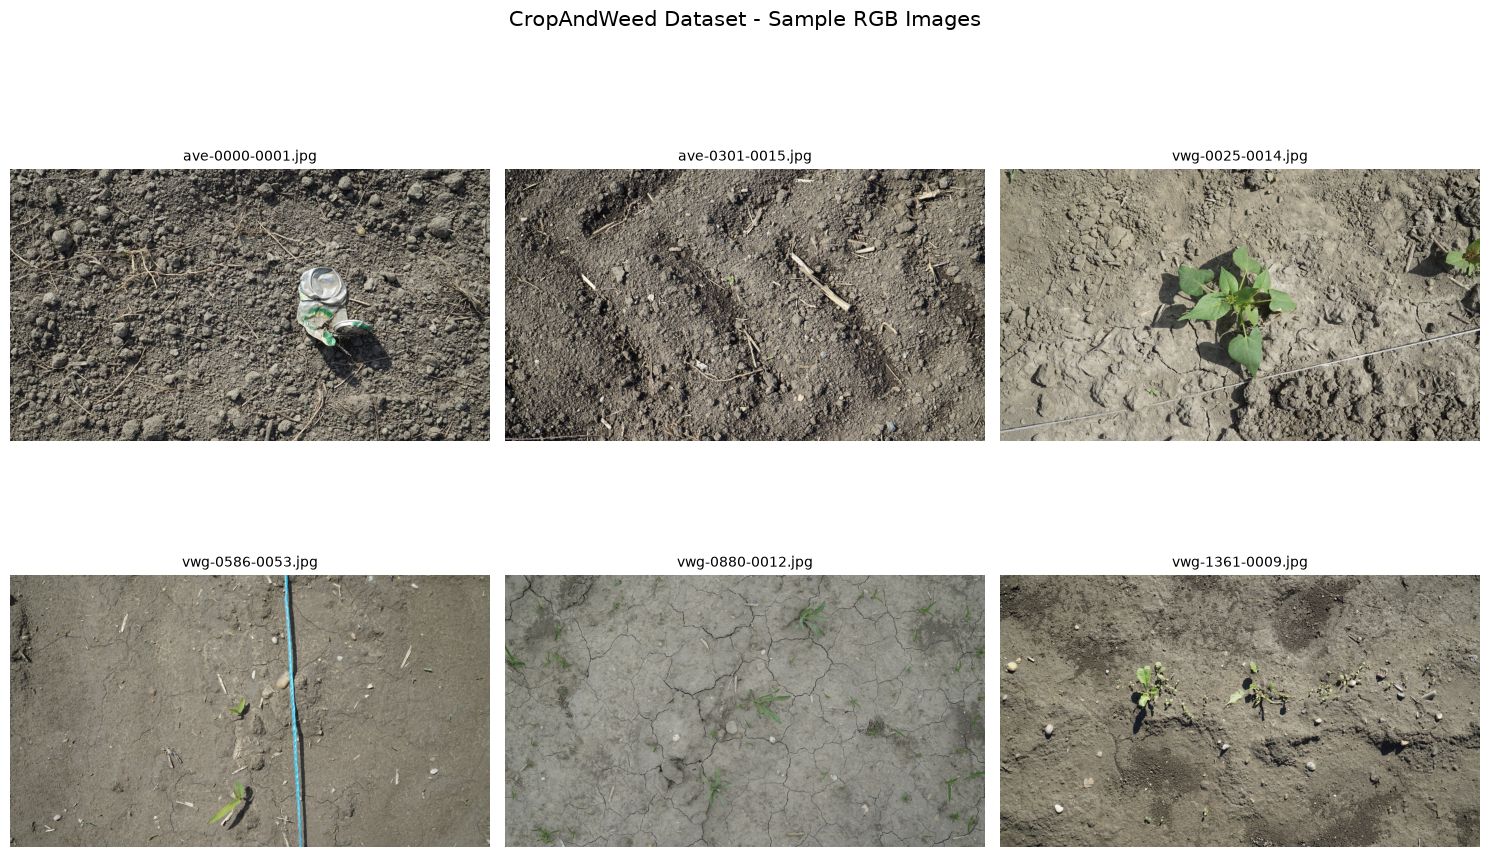

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Select six images evenly across the dataset
sample_indices = np.linspace(
    0,
    len(image_files) - 1,
    6,
    dtype=int
)

print("Selected indices:", sample_indices)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, idx in zip(axes.flatten(), sample_indices):
    image_path = image_files[idx]

    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.set_title(image_path.name, fontsize=10)
    ax.axis("off")

plt.suptitle(
    "CropAndWeed Dataset - Sample RGB Images",
    fontsize=15
)

plt.tight_layout()
plt.show()

#### Observation

- 전체 **8,034장의 RGB Image(원본 이미지)**는 모두 **1920 × 1088**의 동일한 Image Resolution(이미지 해상도)을 가지며, **3-channel** 이미지로 구성되어 있다.
- 모든 이미지를 OpenCV로 정상적으로 불러올 수 있어 Unreadable Image(읽기 불가능 이미지)는 확인되지 않았다.
- 이미지는 `uint8` 데이터 형식을 사용하며, Sample Image(샘플 이미지)의 Pixel Value(픽셀 값)는 **0–255** 범위로 확인되었다.
- Sample Image를 시각적으로 점검한 결과, 식물의 크기와 밀집도에 상당한 차이가 있으며 매우 작은 식물부터 비교적 큰 식물까지 다양한 형태가 존재한다.
- Background(배경)는 토양, 자갈, 식물 잔해, 갈라진 지면 등으로 구성되어 있으며 일부 이미지에서는 관개선 및 인공물도 관찰된다.
- 촬영 환경에 따라 강한 햇빛과 그림자가 나타나며, 식물과 배경 사이의 Contrast(대비)에도 차이가 존재한다.
- 이러한 **Object Size(객체 크기), Background Complexity(배경 복잡도), Shadow(그림자), Plant Density(식물 밀집도)** 차이는 이후 Segmentation Labeling(분할 라벨링)과 Auto Labeling(자동 라벨링)의 난이도 및 성능에 영향을 줄 수 있는 주요 요인으로 판단된다.

### DU-05. Annotation Structure (라벨 구조 분석)

CropAndWeed Dataset에서 제공하는 Annotation(라벨) 데이터의 구조와 형식을 확인하낟. 

`bboxes`, `params`, `labelIds` 데이터를 실제로 불러와 각 데이터가 저장하는 정보와 Annotation Schema(라벨 스키마)를 분석한다. 

주요 확인 항목은 다음과 같다. 

- Bounding Box(바운딩 박스) 데이터의 컬럼 및 객체 정보
- Parameter(파라미터) 데이터의 컬럼 및 메타 데이터
- Pixel-level Label(픽셀 단위 라벨)의 이미지 구조 및 값
- 동일한 Image ID(이미지 ID)에 연결된 Annotation간 관게

이를 통해 이후 Class Distribution(클래스 분포), Bounding Box Analysis (바운딩 박스 분석),Segmentation Labeling(분할 라벨링)에 사용할 데이터 구조를 정의한다. 

In [12]:
from pathlib import Path

# Project paths
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data" / "raw"

BBOX_DIR = DATA_DIR / "bboxes"

print("Current working directory:")
print(Path.cwd())

print("\nBBOX directory:")
print(BBOX_DIR.resolve())

print("\nDirectory exists:")
print(BBOX_DIR.exists())

print("\nSample file exists:")
print((BBOX_DIR / "ave-0000-0001.csv").exists())

print("\nNumber of bbox CSV files:")
print(len(list(BBOX_DIR.glob("*.csv"))))

Current working directory:
c:\Projects\data-labeling-portfolio\03_smart_agriculture\notebooks

BBOX directory:
C:\Projects\data-labeling-portfolio\03_smart_agriculture\data\raw\bboxes

Directory exists:
True

Sample file exists:
False

Number of bbox CSV files:
0


In [13]:
ACTUAL_BBOX_DIR = BBOX_DIR / "CropAndWeed"

print("=== Actual Bounding Box Directory ===")
print("Path:", ACTUAL_BBOX_DIR.resolve())
print("Exists:", ACTUAL_BBOX_DIR.exists())

bbox_files = sorted(ACTUAL_BBOX_DIR.glob("*.csv"))

print(f"CSV files: {len(bbox_files):,}")

print("\nFirst 5 files:")
for path in bbox_files[:5]:
    print(path.name)

=== Actual Bounding Box Directory ===
Path: C:\Projects\data-labeling-portfolio\03_smart_agriculture\data\raw\bboxes\CropAndWeed
Exists: True
CSV files: 8,034

First 5 files:
ave-0000-0001.csv
ave-0000-0002.csv
ave-0000-0005.csv
ave-0007-0000.csv
ave-0007-0007.csv


In [14]:
print("=== Current Raw Dataset Status ===")

for name, path in dataset_dirs.items():
    files = [
        p for p in path.rglob("*")
        if p.is_file()
    ]

    print(
        f"{name:<10} | "
        f"Exists: {path.exists()} | "
        f"Files: {len(files):,}"
    )

=== Current Raw Dataset Status ===
images     | Exists: True | Files: 8,034
bboxes     | Exists: True | Files: 8,034
labelIds   | Exists: True | Files: 8,034
params     | Exists: True | Files: 8,034


In [15]:
sample_bbox_path = ACTUAL_BBOX_DIR / "ave-0000-0001.csv"

print("Sample bbox exists:", sample_bbox_path.exists())
print("Sample bbox path:", sample_bbox_path)

Sample bbox exists: True
Sample bbox path: c:\Projects\data-labeling-portfolio\03_smart_agriculture\data\raw\bboxes\CropAndWeed\ave-0000-0001.csv


In [16]:
bbox_files = sorted(ACTUAL_BBOX_DIR.glob("*.csv"))

print("=== Bounding Box Files ===")
print(f"Total files: {len(bbox_files):,}")

print("\nFirst 10 files:")
for path in bbox_files[:10]:
    print(path.name)

=== Bounding Box Files ===
Total files: 8,034

First 10 files:
ave-0000-0001.csv
ave-0000-0002.csv
ave-0000-0005.csv
ave-0007-0000.csv
ave-0007-0007.csv
ave-0032-0006.csv
ave-0035-0001.csv
ave-0035-0002.csv
ave-0035-0003.csv
ave-0035-0004.csv


In [17]:
ACTUAL_BBOX_DIR = BBOX_DIR / "CropAndWeed"

print("=== Actual Bounding Box Directory ===")
print("Path:", ACTUAL_BBOX_DIR.resolve())
print("Exists:", ACTUAL_BBOX_DIR.exists())

bbox_files = sorted(ACTUAL_BBOX_DIR.glob("*.csv"))

print(f"CSV files: {len(bbox_files):,}")

print("\nFirst 10 files:")
for path in bbox_files[:10]:
    print(path.name)

=== Actual Bounding Box Directory ===
Path: C:\Projects\data-labeling-portfolio\03_smart_agriculture\data\raw\bboxes\CropAndWeed
Exists: True
CSV files: 8,034

First 10 files:
ave-0000-0001.csv
ave-0000-0002.csv
ave-0000-0005.csv
ave-0007-0000.csv
ave-0007-0007.csv
ave-0032-0006.csv
ave-0035-0001.csv
ave-0035-0002.csv
ave-0035-0003.csv
ave-0035-0004.csv


In [18]:
print("=== Dataset Subdirectory Structure ===")

for name, base_path in dataset_dirs.items():
    print(f"\n[{name}]")

    items = sorted(base_path.iterdir())

    directories = [p for p in items if p.is_dir()]
    files = [p for p in items if p.is_file()]

    print(f"Direct files       : {len(files):,}")
    print(f"Direct directories : {len(directories):,}")

    if directories:
        print("Subdirectories:")
        for directory in directories[:10]:
            nested_files = [
                p for p in directory.rglob("*")
                if p.is_file()
            ]

            print(
                f"  {directory.name:<20} "
                f"| Files: {len(nested_files):,}"
            )

=== Dataset Subdirectory Structure ===

[images]
Direct files       : 8,034
Direct directories : 0

[bboxes]
Direct files       : 0
Direct directories : 1
Subdirectories:
  CropAndWeed          | Files: 8,034

[labelIds]
Direct files       : 0
Direct directories : 1
Subdirectories:
  CropAndWeed          | Files: 8,034

[params]
Direct files       : 8,034
Direct directories : 0


In [19]:
# Annotation directories
IMAGE_DIR = dataset_dirs["images"]
BBOX_DIR = dataset_dirs["bboxes"] / "CropAndWeed"
LABEL_DIR = dataset_dirs["labelIds"] / "CropAndWeed"
PARAM_DIR = dataset_dirs["params"]

print("=== Annotation Directory Setup ===")
print(f"Images   : {IMAGE_DIR}")
print(f"BBoxes   : {BBOX_DIR}")
print(f"Label IDs: {LABEL_DIR}")
print(f"Params   : {PARAM_DIR}")

print("\n=== File Counts ===")
print(f"Images   : {len(list(IMAGE_DIR.glob('*.jpg'))):,}")
print(f"BBoxes   : {len(list(BBOX_DIR.glob('*.csv'))):,}")
print(f"Label IDs: {len(list(LABEL_DIR.glob('*.png'))):,}")
print(f"Params   : {len(list(PARAM_DIR.glob('*.csv'))):,}")

=== Annotation Directory Setup ===
Images   : ..\data\raw\images
BBoxes   : ..\data\raw\bboxes\CropAndWeed
Label IDs: ..\data\raw\labelIds\CropAndWeed
Params   : ..\data\raw\params

=== File Counts ===
Images   : 8,034
BBoxes   : 8,034
Label IDs: 8,034
Params   : 8,034


In [20]:
import pandas as pd

sample_bbox_df = pd.read_csv(
    sample_bbox_path,
    header=None
)

print("=== Bounding Box Annotation ===")
print(f"File       : {sample_bbox_path.name}")
print(f"Shape      : {sample_bbox_df.shape}")
print(f"Columns    : {sample_bbox_df.columns.tolist()}")

print("\n=== Data Types ===")
print(sample_bbox_df.dtypes)

print("\n=== Sample Rows ===")
display(sample_bbox_df.head(10))

print("\n=== Raw File Content ===")

with open(sample_bbox_path, "r") as f:
    for i, line in enumerate(f):
        print(repr(line.strip()))
        if i >= 9:
            break

=== Bounding Box Annotation ===
File       : ave-0000-0001.csv
Shape      : (1, 7)
Columns    : [0, 1, 2, 3, 4, 5, 6]

=== Data Types ===
0    int64
1    int64
2    int64
3    int64
4    int64
5    int64
6    int64
dtype: object

=== Sample Rows ===


,0,1,2,3,4,5,6
0,446,329,475,356,48,461,342



=== Raw File Content ===
'446,329,475,356,48,461,342'


In [21]:
sample_param_path = PARAM_DIR / sample_bbox_path.name

print("=== Parameter File Check ===")
print(f"File   : {sample_param_path.name}")
print(f"Exists : {sample_param_path.exists()}")

print("\n=== Raw Parameter Content ===")

with open(sample_param_path, "r") as f:
    for i, line in enumerate(f):
        print(repr(line.strip()))
        if i >= 9:
            break

=== Parameter File Check ===
File   : ave-0000-0001.csv
Exists : True

=== Raw Parameter Content ===
'moisture,soil,lighting,separability'
'0,1,0,0'


In [22]:
sample_param_df = pd.read_csv(sample_param_path)

print("\n=== Parameter Data ===")
print(f"Shape      : {sample_param_df.shape}")
print(f"Columns    : {sample_param_df.columns.tolist()}")

print("\n=== Data Types ===")
print(sample_param_df.dtypes)

print("\n=== Sample Rows ===")
display(sample_param_df.head(10))


=== Parameter Data ===
Shape      : (1, 4)
Columns    : ['moisture', 'soil', 'lighting', 'separability']

=== Data Types ===
moisture        int64
soil            int64
lighting        int64
separability    int64
dtype: object

=== Sample Rows ===


,moisture,soil,lighting,separability
0,0,1,0,0


In [23]:
sample_param_df = pd.read_csv(sample_param_path)

print("=== Parameter Data ===")
print(f"File       : {sample_param_path.name}")
print(f"Shape      : {sample_param_df.shape}")
print(f"Columns    : {sample_param_df.columns.tolist()}")

print("\n=== Data Types ===")
print(sample_param_df.dtypes)

print("\n=== Sample Rows ===")
display(sample_param_df)

=== Parameter Data ===
File       : ave-0000-0001.csv
Shape      : (1, 4)
Columns    : ['moisture', 'soil', 'lighting', 'separability']

=== Data Types ===
moisture        int64
soil            int64
lighting        int64
separability    int64
dtype: object

=== Sample Rows ===


,moisture,soil,lighting,separability
0,0,1,0,0


In [24]:
import numpy as np

sample_label_path = LABEL_DIR / sample_bbox_path.with_suffix(".png").name

sample_label = cv2.imread(
    str(sample_label_path),
    cv2.IMREAD_UNCHANGED
)

print("=== Pixel-level Label ===")
print(f"File       : {sample_label_path.name}")
print(f"Exists     : {sample_label_path.exists()}")
print(f"Shape      : {sample_label.shape}")
print(f"Data type  : {sample_label.dtype}")
print(f"Min value  : {sample_label.min()}")
print(f"Max value  : {sample_label.max()}")

unique_values, counts = np.unique(
    sample_label,
    return_counts=True
)

print(f"\nUnique values : {len(unique_values):,}")
print("Values        :", unique_values)

print("\n=== Pixel Counts ===")
for value, count in zip(unique_values, counts):
    print(f"Value {value:>3}: {count:,}")

=== Pixel-level Label ===
File       : ave-0000-0001.png
Exists     : True
Shape      : (1088, 1920)
Data type  : uint8
Min value  : 0
Max value  : 48

Unique values : 2
Values        : [ 0 48]

=== Pixel Counts ===
Value   0: 2,088,710
Value  48: 250


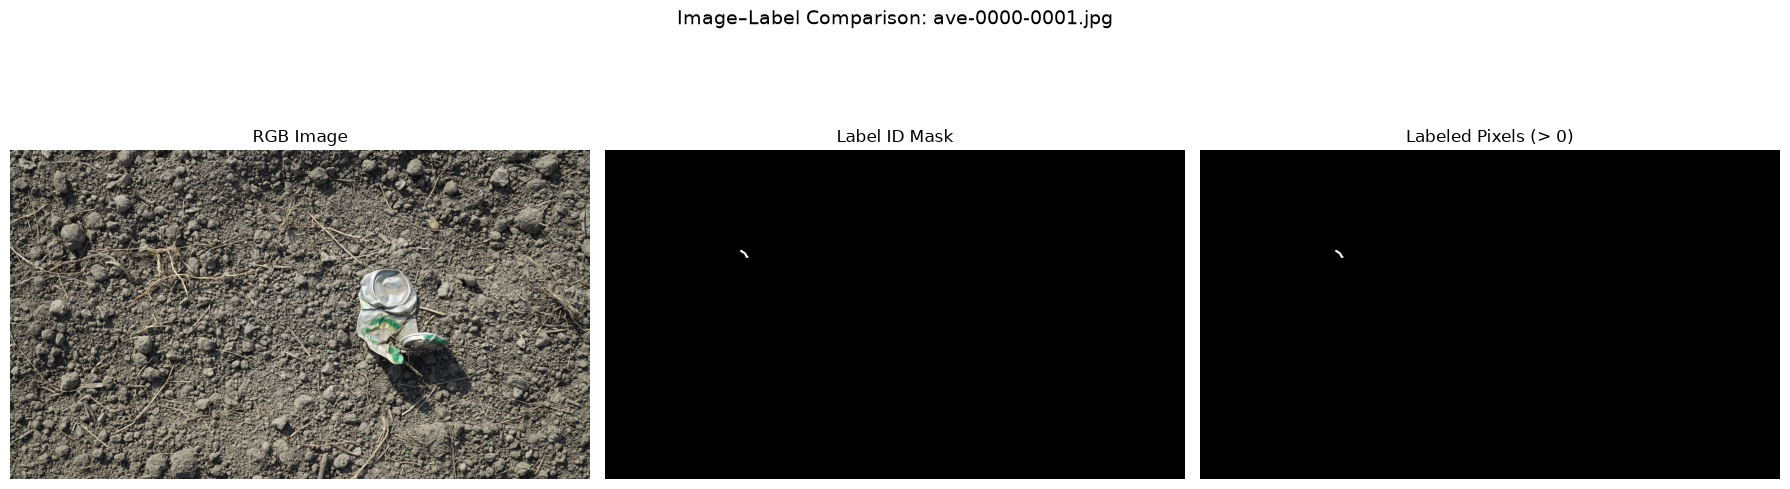

In [25]:
import matplotlib.pyplot as plt

# Corresponding RGB image
sample_image_path = IMAGE_DIR / sample_bbox_path.with_suffix(".jpg").name
sample_image = cv2.imread(str(sample_image_path))
sample_image_rgb = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

# Binary visualization of labeled pixels
binary_mask = sample_label > 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RGB image
axes[0].imshow(sample_image_rgb)
axes[0].set_title("RGB Image")
axes[0].axis("off")

# Original label ID mask
axes[1].imshow(sample_label, cmap="gray")
axes[1].set_title("Label ID Mask")
axes[1].axis("off")

# Binary mask
axes[2].imshow(binary_mask, cmap="gray")
axes[2].set_title("Labeled Pixels (> 0)")
axes[2].axis("off")

plt.suptitle(
    f"Image–Label Comparison: {sample_image_path.name}",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [26]:
# Extract coordinates of the non-zero labeled pixels
ys, xs = np.where(sample_label > 0)

mask_x_min = xs.min()
mask_x_max = xs.max()
mask_y_min = ys.min()
mask_y_max = ys.max()

mask_center_x = xs.mean()
mask_center_y = ys.mean()

print("=== Mask Spatial Analysis ===")
print(f"X range       : {mask_x_min} ~ {mask_x_max}")
print(f"Y range       : {mask_y_min} ~ {mask_y_max}")
print(f"Center X      : {mask_center_x:.2f}")
print(f"Center Y      : {mask_center_y:.2f}")

print("\n=== Bounding Box Raw Values ===")
print(sample_bbox_df.iloc[0].tolist())

=== Mask Spatial Analysis ===
X range       : 447 ~ 474
Y range       : 330 ~ 355
Center X      : 461.27
Center Y      : 341.90

=== Bounding Box Raw Values ===
[446, 329, 475, 356, 48, 461, 342]


In [27]:
from pandas.errors import EmptyDataError

# Find a bounding box file containing multiple objects
multi_bbox_path = None
multi_bbox_df = None

for path in bbox_files:
    try:
        df = pd.read_csv(path, header=None)
    except EmptyDataError:
        # Skip images with no bounding box annotations
        continue

    if len(df) >= 3:
        multi_bbox_path = path
        multi_bbox_df = df
        break

print("=== Multi-object Bounding Box Sample ===")

if multi_bbox_path is not None:
    print(f"File       : {multi_bbox_path.name}")
    print(f"Objects    : {len(multi_bbox_df)}")
    display(multi_bbox_df)
else:
    print("No file with 3 or more objects was found.")

=== Multi-object Bounding Box Sample ===
File       : ave-0007-0000.csv
Objects    : 105


,0,1,2,3,4,5,6
0,119,52,141,84,83,130,68
1,292,36,311,66,35,301,51
2,310,49,321,68,255,316,58
3,347,42,357,63,255,352,52
4,683,54,723,69,24,703,62
...,...,...,...,...,...,...,...
100,1345,51,1358,69,255,1351,60
101,1540,29,1554,41,255,1546,35
102,1602,36,1612,47,255,1607,41
103,1661,0,1672,15,255,1666,7


In [28]:
multi_label_path = LABEL_DIR / multi_bbox_path.with_suffix(".png").name

multi_label = cv2.imread(
    str(multi_label_path),
    cv2.IMREAD_UNCHANGED
)

# Non-zero IDs in segmentation mask
mask_ids = np.unique(multi_label)
mask_ids = mask_ids[mask_ids != 0]

# Fifth column in bounding box CSV
bbox_ids = multi_bbox_df.iloc[:, 4].unique()

print("=== Bounding Box ↔ Mask ID Check ===")
print(f"BBox unique IDs : {len(bbox_ids)}")
print(f"Mask unique IDs : {len(mask_ids)}")

print("\nBBox IDs:")
print(np.sort(bbox_ids))

print("\nMask IDs:")
print(np.sort(mask_ids))

print("\n=== ID Comparison ===")
print(
    "Exact ID match :",
    set(bbox_ids) == set(mask_ids)
)

print(
    "BBox only IDs  :",
    sorted(set(bbox_ids) - set(mask_ids))
)

print(
    "Mask only IDs  :",
    sorted(set(mask_ids) - set(bbox_ids))
)

=== Bounding Box ↔ Mask ID Check ===
BBox unique IDs : 12
Mask unique IDs : 12

BBox IDs:
[  7  24  33  35  38  39  42  48  57  83  89 255]

Mask IDs:
[  7  24  33  35  38  39  42  48  57  83  89 255]

=== ID Comparison ===
Exact ID match : True
BBox only IDs  : []
Mask only IDs  : []


In [29]:
center_check = multi_bbox_df.copy()

center_check["calc_center_x"] = (
    (center_check[0] + center_check[2]) / 2
).round().astype(int)

center_check["calc_center_y"] = (
    (center_check[1] + center_check[3]) / 2
).round().astype(int)

center_check["x_match"] = (
    center_check["calc_center_x"] == center_check[5]
)

center_check["y_match"] = (
    center_check["calc_center_y"] == center_check[6]
)

print("=== Bounding Box Center Validation ===")
print(f"Objects          : {len(center_check):,}")
print(f"Center X matches : {center_check['x_match'].sum():,}")
print(f"Center Y matches : {center_check['y_match'].sum():,}")

print(
    "Both match      :",
    (center_check["x_match"] & center_check["y_match"]).sum()
)

display(
    center_check[
        [0, 1, 2, 3, 5, 6, "calc_center_x", "calc_center_y",
         "x_match", "y_match"]
    ].head(10)
)

=== Bounding Box Center Validation ===
Objects          : 105
Center X matches : 57
Center Y matches : 63
Both match      : 41


,0,1,2,3,5,6,calc_center_x,calc_center_y,x_match,y_match
0,119,52,141,84,130,68,130,68,True,True
1,292,36,311,66,301,51,302,51,False,True
2,310,49,321,68,316,58,316,58,True,True
3,347,42,357,63,352,52,352,52,True,True
4,683,54,723,69,703,62,703,62,True,True
5,856,58,870,66,863,62,863,62,True,True
6,0,363,59,484,29,424,30,424,False,True
7,100,332,115,350,108,341,108,341,True,True
8,121,335,137,358,129,346,129,346,True,True
9,161,323,202,355,197,350,182,339,False,False


In [30]:
centroid_results = []

for _, row in multi_bbox_df.iterrows():

    label_id = int(row[4])

    # Pixels belonging to this label ID
    ys, xs = np.where(multi_label == label_id)

    if len(xs) == 0:
        continue

    mask_center_x = xs.mean()
    mask_center_y = ys.mean()

    centroid_results.append({
        "label_id": label_id,
        "csv_x": row[5],
        "csv_y": row[6],
        "mask_centroid_x": mask_center_x,
        "mask_centroid_y": mask_center_y,
        "x_difference": abs(row[5] - mask_center_x),
        "y_difference": abs(row[6] - mask_center_y)
    })

centroid_df = pd.DataFrame(centroid_results)

print("=== CSV Coordinate ↔ Mask Centroid Check ===")

display(centroid_df.head(15))

print("\n=== Mean Absolute Difference ===")
print(
    f"X difference : "
    f"{centroid_df['x_difference'].mean():.2f} pixels"
)
print(
    f"Y difference : "
    f"{centroid_df['y_difference'].mean():.2f} pixels"
)

=== CSV Coordinate ↔ Mask Centroid Check ===


,label_id,csv_x,csv_y,mask_centroid_x,mask_centroid_y,x_difference,y_difference
0,83,130,68,129.187117,66.815951,0.812883,1.184049
1,35,301,51,773.758448,322.352689,472.758448,271.352689
2,255,316,58,959.677056,532.414418,643.677056,474.414418
3,255,352,52,959.677056,532.414418,607.677056,480.414418
4,24,703,62,669.852982,288.920943,33.147018,226.920943
5,255,863,62,959.677056,532.414418,96.677056,470.414418
6,7,29,424,567.626774,359.639938,538.626774,64.360062
7,35,108,341,773.758448,322.352689,665.758448,18.647311
8,35,129,346,773.758448,322.352689,644.758448,23.647311
9,48,197,350,991.533955,345.360946,794.533955,4.639054



=== Mean Absolute Difference ===
X difference : 437.93 pixels
Y difference : 213.91 pixels


In [31]:
# Initial check using the global mask centroid for each label ID
centroid_results = []

for _, row in multi_bbox_df.iterrows():

    label_id = int(row[4])

    # Find all pixels belonging to the same label ID
    ys, xs = np.where(multi_label == label_id)

    if len(xs) == 0:
        continue

    # Global mask centroid for this label ID
    mask_center_x = xs.mean()
    mask_center_y = ys.mean()

    centroid_results.append({
        "label_id": label_id,
        "csv_x": row[5],
        "csv_y": row[6],
        "mask_centroid_x": mask_center_x,
        "mask_centroid_y": mask_center_y,
        "x_difference": abs(row[5] - mask_center_x),
        "y_difference": abs(row[6] - mask_center_y)
    })

centroid_df = pd.DataFrame(centroid_results)

print("=== Initial Check: Global Mask Centroid by Label ID ===")

display(centroid_df.head(15))

print("\n=== Mean Absolute Difference ===")

print(
    f"X difference : "
    f"{centroid_df['x_difference'].mean():.2f} pixels"
)

print(
    f"Y difference : "
    f"{centroid_df['y_difference'].mean():.2f} pixels"
)

=== Initial Check: Global Mask Centroid by Label ID ===


,label_id,csv_x,csv_y,mask_centroid_x,mask_centroid_y,x_difference,y_difference
0,83,130,68,129.187117,66.815951,0.812883,1.184049
1,35,301,51,773.758448,322.352689,472.758448,271.352689
2,255,316,58,959.677056,532.414418,643.677056,474.414418
3,255,352,52,959.677056,532.414418,607.677056,480.414418
4,24,703,62,669.852982,288.920943,33.147018,226.920943
5,255,863,62,959.677056,532.414418,96.677056,470.414418
6,7,29,424,567.626774,359.639938,538.626774,64.360062
7,35,108,341,773.758448,322.352689,665.758448,18.647311
8,35,129,346,773.758448,322.352689,644.758448,23.647311
9,48,197,350,991.533955,345.360946,794.533955,4.639054



=== Mean Absolute Difference ===
X difference : 437.93 pixels
Y difference : 213.91 pixels


In [32]:
# Calculate local mask centroid within each bounding box
local_centroid_results = []

for row_idx, row in multi_bbox_df.iterrows():

    x_min = int(row[0])
    y_min = int(row[1])
    x_max = int(row[2])
    y_max = int(row[3])

    label_id = int(row[4])
    stem_x = float(row[5])
    stem_y = float(row[6])

    # Crop the mask to the current bounding box
    local_mask = multi_label[
        y_min:y_max + 1,
        x_min:x_max + 1
    ]

    # Find pixels belonging to this label ID inside the bbox
    local_ys, local_xs = np.where(local_mask == label_id)

    if len(local_xs) == 0:
        continue

    # Convert local coordinates back to full-image coordinates
    mask_centroid_x = local_xs.mean() + x_min
    mask_centroid_y = local_ys.mean() + y_min

    local_centroid_results.append({
        "row": row_idx,
        "label_id": label_id,
        "csv_x": stem_x,
        "csv_y": stem_y,
        "mask_centroid_x": mask_centroid_x,
        "mask_centroid_y": mask_centroid_y,
        "x_difference": abs(stem_x - mask_centroid_x),
        "y_difference": abs(stem_y - mask_centroid_y)
    })

local_centroid_df = pd.DataFrame(local_centroid_results)

print("=== Local Mask Centroid Validation ===")
print(f"Objects checked           : {len(local_centroid_df):,}")
print(
    f"Mean absolute difference  : "
    f"X {local_centroid_df['x_difference'].mean():.2f} px | "
    f"Y {local_centroid_df['y_difference'].mean():.2f} px"
)
print(
    f"Median absolute difference: "
    f"X {local_centroid_df['x_difference'].median():.2f} px | "
    f"Y {local_centroid_df['y_difference'].median():.2f} px"
)

display(local_centroid_df.head(10))

=== Local Mask Centroid Validation ===
Objects checked           : 105
Mean absolute difference  : X 4.45 px | Y 3.70 px
Median absolute difference: X 0.52 px | Y 0.52 px


,row,label_id,csv_x,csv_y,mask_centroid_x,mask_centroid_y,x_difference,y_difference
0,0,83,130.0,68.0,129.187117,66.815951,0.812883,1.184049
1,1,35,301.0,51.0,300.980583,50.475728,0.019417,0.524272
2,2,255,316.0,58.0,315.750000,58.680556,0.250000,0.680556
3,3,255,352.0,52.0,351.553459,52.345912,0.446541,0.345912
4,4,24,703.0,62.0,703.415473,61.873926,0.415473,0.126074
5,5,255,863.0,62.0,862.972973,61.905405,0.027027,0.094595
6,6,7,29.0,424.0,21.409842,416.416763,7.590158,7.583237
7,7,35,108.0,341.0,108.437126,342.113772,0.437126,1.113772
8,8,35,129.0,346.0,129.413669,345.974820,0.413669,0.025180
9,9,48,197.0,350.0,182.009238,340.745958,14.990762,9.254042


In [33]:
# Define centroid matching tolerance
TOLERANCE = 2.0

local_centroid_df["within_tolerance"] = (
    (local_centroid_df["x_difference"] <= TOLERANCE) &
    (local_centroid_df["y_difference"] <= TOLERANCE)
)

matched_count = local_centroid_df["within_tolerance"].sum()
total_count = len(local_centroid_df)

print("=== Stem Point vs. Local Mask Centroid Summary ===")
print(f"Total objects       : {total_count:,}")
print(f"Within ±2 px        : {matched_count:,}")
print(f"Outside ±2 px       : {total_count - matched_count:,}")
print(f"Within ±2 px rate : {matched_count / total_count * 100:.2f}%")

print("\n=== Largest Differences ===")

outliers = local_centroid_df.copy()

outliers["max_difference"] = outliers[
    ["x_difference", "y_difference"]
].max(axis=1)

display(
    outliers.sort_values(
        "max_difference",
        ascending=False
    ).head(10)
)

=== Stem Point vs. Local Mask Centroid Summary ===
Total objects       : 105
Within ±2 px        : 80
Outside ±2 px       : 25
Within ±2 px rate : 76.19%

=== Largest Differences ===


,row,label_id,csv_x,csv_y,mask_centroid_x,mask_centroid_y,x_difference,y_difference,within_tolerance,max_difference
38,38,48,1173.0,242.0,1077.920244,207.018301,95.079756,34.981699,False,95.079756
10,10,48,245.0,404.0,197.737788,355.138710,47.262212,48.861290,False,48.861290
57,57,48,1909.0,882.0,1870.514184,883.204492,38.485816,1.204492,False,38.485816
72,72,38,1718.0,953.0,1753.861276,929.615197,35.861276,23.384803,False,35.861276
73,73,38,950.0,315.0,914.330152,346.222487,35.669848,31.222487,False,35.669848
29,29,33,314.0,248.0,285.312160,237.503630,28.687840,10.496370,False,28.687840
65,65,38,1032.0,444.0,1026.350262,418.964921,5.649738,25.035079,False,25.035079
68,68,48,1329.0,299.0,1316.724543,321.624021,12.275457,22.624021,False,22.624021
56,56,48,1528.0,797.0,1549.592105,777.186842,21.592105,19.813158,False,21.592105
39,39,89,1162.0,218.0,1159.715596,196.924771,2.284404,21.075229,False,21.075229


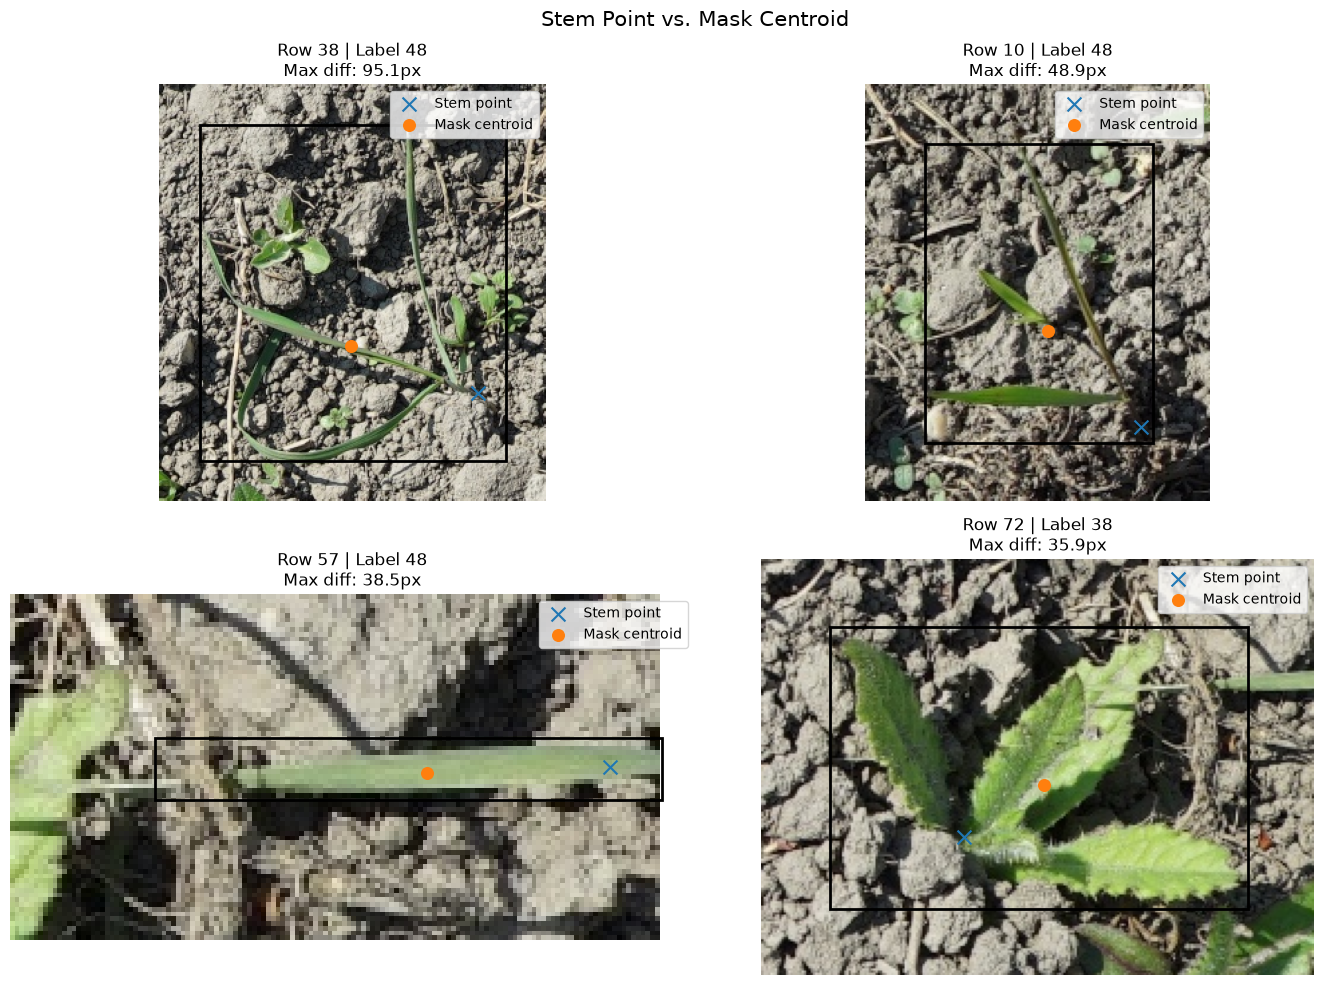

In [34]:
# Select top 4 centroid outliers
top_outliers = (
    outliers
    .sort_values("max_difference", ascending=False)
    .head(4)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (_, result) in zip(axes, top_outliers.iterrows()):

    row_idx = int(result["row"])
    bbox_row = multi_bbox_df.loc[row_idx]

    x_min = int(bbox_row[0])
    y_min = int(bbox_row[1])
    x_max = int(bbox_row[2])
    y_max = int(bbox_row[3])
    
    stem_x = int(bbox_row[5])
    stem_y = int(bbox_row[6])

    mask_x = result["mask_centroid_x"]
    mask_y = result["mask_centroid_y"]

    # Crop RGB image around bbox with margin
    margin = 30

    crop_x_min = max(0, x_min - margin)
    crop_y_min = max(0, y_min - margin)
    crop_x_max = min(sample_image_rgb.shape[1], x_max + margin)
    crop_y_max = min(sample_image_rgb.shape[0], y_max + margin)

    # Load corresponding multi-object RGB image
    multi_image_path = IMAGE_DIR / multi_bbox_path.with_suffix(".jpg").name

    multi_image = cv2.imread(str(multi_image_path))
    multi_image_rgb = cv2.cvtColor(
        multi_image,
        cv2.COLOR_BGR2RGB
    )

    crop = multi_image_rgb[
        crop_y_min:crop_y_max,
        crop_x_min:crop_x_max
    ]

    ax.imshow(crop)

    # Bounding box
    rect = plt.Rectangle(
        (x_min - crop_x_min, y_min - crop_y_min),
        x_max - x_min,
        y_max - y_min,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    # CSV coordinate
    ax.scatter(
        stem_x - crop_x_min,
        stem_y - crop_y_min,
        marker="x",
        s=100,
        label="Stem point"
    )

    # Calculated mask centroid
    ax.scatter(
        mask_x - crop_x_min,
        mask_y - crop_y_min,
        marker="o",
        s=70,
        label="Mask centroid"
    )

    ax.set_title(
        f"Row {row_idx} | Label {int(result['label_id'])}\n"
        f"Max diff: {result['max_difference']:.1f}px"
    )

    ax.axis("off")
    ax.legend()

plt.suptitle(
    "Stem Point vs. Mask Centroid",
    fontsize=15
)

plt.tight_layout()
plt.show()

#### DU-05-13. Bounding Box CSV Schema 확인

Bounding Box(바운딩 박스) CSV 파일은 객체별로 7개의 값을 포함하고 있다. 

앞선 분석을 통해 처음 5개 값은 Bounding Box 좌표와 Label ID(라벨 ID)에 대응하는 것을 확인하였다. 
그러나 마지막 두 좌표는 Bounding Box Center(바운딩 박스 중심) 및 Mask Centroid(마스크 중심점)와 높은 유사성을 보이면서도 일부 객체에서 큰 차이가 관찰되었다. 

따라서 CropAndWeed Dataset(데이터셋)의 원본 코드를 확인하여 Bounding Box CSV의 각 Column(컬럼)이 어떤 방식으로 생성되는지 검증한다. 

#### DU-05-14. Bounding Box Schema Verification (바운딩 박스 스키마 검증)

CropAndWeed Dataset(데이터셋)의 Bounding Box CSV는 Header(헤더)가 없는
7개의 Column(컬럼)으로 구성되어 있다.

초기 데이터 분석에서는 마지막 두 좌표가 Bounding Box Center(바운딩 박스 중심) 또는
Mask Centroid(마스크 중심점)일 가능성을 검토하였다.

Mask(마스크)와의 공간적 비교 결과, 다수 객체에서는 두 좌표가 Mask Centroid와
가까웠으나 일부 객체에서는 큰 위치 차이가 확인되었다.

Dataset Source Code(데이터셋 원본 코드)의 `visualize_annotations.py`와
`map_dataset.py`를 확인한 결과 공식 Schema는 다음과 같이 정의되어 있다.

| Column | Field | Description |
|---|---|---|
| 0 | left | Bounding Box의 왼쪽 X 좌표 |
| 1 | top | Bounding Box의 위쪽 Y 좌표 |
| 2 | right | Bounding Box의 오른쪽 X 좌표 |
| 3 | bottom | Bounding Box의 아래쪽 Y 좌표 |
| 4 | label_id | 객체 및 Segmentation Mask와 연결되는 Label ID |
| 5 | stem_x | 식물 Stem(줄기) 위치의 X 좌표 |
| 6 | stem_y | 식물 Stem(줄기) 위치의 Y 좌표 |

따라서 마지막 두 좌표는 객체의 기하학적 중심이 아니라
Stem Point(줄기 위치)를 나타내는 Annotation(라벨링) 정보임을 확인하였다.

#### DU-05-15. Bounding Box Annotation Structure Validation (바운딩 박스 라벨링 구조 검증)

CropAndWeed Dataset(데이터셋)의 Source Code(원본 코드)를 통해 확인한
Bounding Box Annotation(바운딩 박스 라벨링) Schema(스키마)를 기준으로
전체 Bounding Box CSV 파일의 구조를 검증한다.

각 Annotation(라벨링)은 `left`, `top`, `right`, `bottom`, `label_id`,
`stem_x`, `stem_y`의 7개 Field(필드)로 구성되며,
전체 파일에서 동일한 구조가 유지되는지 확인한다.

In [35]:
BBOX_COLUMNS = [
    "left",
    "top",
    "right",
    "bottom",
    "label_id",
    "stem_x",
    "stem_y"
]

total_files = len(bbox_files)
valid_files = 0
empty_files = 0
invalid_column_files = 0
total_annotations = 0

for path in bbox_files:
    try:
        df = pd.read_csv(path, header=None)

        if df.empty:
            empty_files += 1
            continue

        if df.shape[1] != len(BBOX_COLUMNS):
            invalid_column_files += 1
            continue

        df.columns = BBOX_COLUMNS

        valid_files += 1
        total_annotations += len(df)

    except pd.errors.EmptyDataError:
        empty_files += 1

print("=== Bounding Box Dataset Validation ===")
print(f"Total CSV files       : {total_files:,}")
print(f"Non-empty files       : {valid_files:,}")
print(f"Empty files           : {empty_files:,}")
print(f"Invalid column files  : {invalid_column_files:,}")
print(f"Total annotations     : {total_annotations:,}")

if total_files > 0:
    print(
        f"Non-empty file rate   : "
        f"{valid_files / total_files * 100:.2f}%"
    )

=== Bounding Box Dataset Validation ===
Total CSV files       : 8,034
Non-empty files       : 7,800
Empty files           : 234
Invalid column files  : 0
Total annotations     : 111,953
Non-empty file rate   : 97.09%


#### DU-05-16. Empty Annotation File Validation (빈 라벨링 파일 검증)

전체 8,034개의 Bounding Box CSV 중 234개가 Empty File(빈 파일)로 확인되었다.

빈 CSV가 Dataset Error(데이터셋 오류)를 의미하는지,
또는 라벨링 대상 객체가 존재하지 않는 정상적인 Negative Sample(음성 샘플)인지 확인하기 위해
동일 이미지의 Label ID Mask(라벨 ID 마스크)를 비교한다.

빈 Bounding Box CSV에 대응하는 Mask에서 Non-zero Label ID(0이 아닌 라벨 ID)가
존재하는지 확인하여 Annotation(라벨링) 간 일관성을 검증한다.

In [36]:
# Collect empty bounding-box files
empty_bbox_files = []

for path in bbox_files:
    try:
        df = pd.read_csv(path, header=None)

        if df.empty:
            empty_bbox_files.append(path)

    except pd.errors.EmptyDataError:
        empty_bbox_files.append(path)

print("=== Empty Bounding Box Files ===")
print(f"Empty files: {len(empty_bbox_files):,}")

print("\nFirst 10 files:")
for path in empty_bbox_files[:10]:
    print(path.name)

=== Empty Bounding Box Files ===
Empty files: 234

First 10 files:
ave-0000-0002.csv
ave-0000-0005.csv
ave-0217-0001.csv
ave-0223-0014.csv
ave-0223-0015.csv
ave-0223-0016.csv
ave-0223-0020.csv
ave-0238-0016.csv
ave-0293-0007.csv
ave-0293-0008.csv


In [37]:
empty_mask_results = []

for bbox_path in empty_bbox_files:

    mask_path = LABEL_DIR / bbox_path.with_suffix(".png").name

    if not mask_path.exists():
        empty_mask_results.append(
            (bbox_path.name, False, None)
        )
        continue

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_UNCHANGED
    )

    nonzero_pixels = int(np.count_nonzero(mask))

    empty_mask_results.append(
        (bbox_path.name, True, nonzero_pixels)
    )

empty_mask_df = pd.DataFrame(
    empty_mask_results,
    columns=[
        "bbox_file",
        "mask_exists",
        "nonzero_pixels"
    ]
)

print("=== Empty BBox vs. Label Mask Check ===")
print(f"Files checked          : {len(empty_mask_df):,}")
print(f"Missing masks          : {(~empty_mask_df['mask_exists']).sum():,}")
print(
    f"Masks with labels      : "
    f"{(empty_mask_df['nonzero_pixels'].fillna(0) > 0).sum():,}"
)
print(
    f"Masks without labels   : "
    f"{(empty_mask_df['nonzero_pixels'].fillna(0) == 0).sum():,}"
)

=== Empty BBox vs. Label Mask Check ===
Files checked          : 234
Missing masks          : 0
Masks with labels      : 0
Masks without labels   : 234


#### DU-05-17. Bounding Box Annotation Validation Summary (바운딩 박스 라벨링 검증 요약)

전체 8,034개의 Bounding Box Annotation(바운딩 박스 라벨링) CSV를 검증한 결과,
7,800개 파일에서 총 111,953개의 객체 라벨링을 확인하였다.

나머지 234개 파일은 Empty CSV(빈 CSV)였으나, 대응하는 Label ID Mask(라벨 ID 마스크)를
교차 검증한 결과 모든 파일에서 Non-zero Label Pixel(0이 아닌 라벨 픽셀)이 존재하지 않았다.
따라서 해당 파일들은 라벨링 누락이 아니라 객체가 존재하지 않는
Negative Sample(음성 샘플)로 판단하였다.

또한 Non-empty CSV(비어 있지 않은 CSV)에서는 잘못된 Column(컬럼) 구조가 발견되지 않았으며,
Source Code(원본 코드)를 통해 Bounding Box Annotation의 공식 Schema가 다음과 같음을 확인하였다.

`left, top, right, bottom, label_id, stem_x, stem_y`

이를 통해 전체 8,034개 이미지에 대응하는 Bounding Box Annotation 구조가
일관되게 구성되어 있음을 확인하였다.

In [38]:
total_dataset_files = total_files
negative_samples = empty_files
positive_samples = valid_files

missing_masks = (~empty_mask_df["mask_exists"]).sum()
inconsistent_empty_files = (
    empty_mask_df["nonzero_pixels"].fillna(0) > 0
).sum()

consistent_files = (
    total_dataset_files
    - invalid_column_files
    - missing_masks
    - inconsistent_empty_files
)

consistency_rate = (
    consistent_files / total_dataset_files * 100
)

print("=== DU-05 Final Validation Summary ===")
print(f"Total images / BBox files        : {total_dataset_files:,}")
print(f"Positive samples                 : {positive_samples:,}")
print(f"Negative samples                 : {negative_samples:,}")
print(f"Total annotations                : {total_annotations:,}")
print(f"Invalid schema files             : {invalid_column_files:,}")
print(f"Missing masks                    : {missing_masks:,}")
print(f"Inconsistent empty files         : {inconsistent_empty_files:,}")
print(f"BBox–Mask structural consistency : {consistency_rate:.2f}%")

=== DU-05 Final Validation Summary ===
Total images / BBox files        : 8,034
Positive samples                 : 7,800
Negative samples                 : 234
Total annotations                : 111,953
Invalid schema files             : 0
Missing masks                    : 0
Inconsistent empty files         : 0
BBox–Mask structural consistency : 100.00%
